In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from flonacomldft.utils.io_utils import get_project_path

# Minima energy spectra

In [25]:
path_opt_spc_dft = get_project_path() + '/8-optical-spectra'

In [26]:
data0K_is0 = np.loadtxt(path_opt_spc_dft +'/minima_is0/spectrum_with_05.50eV.dat', skiprows=1)
data0K_is1 = np.loadtxt(path_opt_spc_dft +'/minima_is1/spectrum_with_05.50eV.dat', skiprows=1)

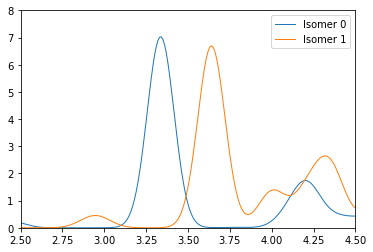

In [27]:
fig, ax = plt.subplots()
ax.plot(data0K_is0[:,0],data0K_is0[:,1], lw=1, label="Isomer 0")
ax.plot(data0K_is1[:,0],data0K_is1[:,1], lw=1, label="Isomer 1")
ax.set_xlim(2.5, 4.5)
ax.set_ylim(0, 8)
ax.legend()

# MD

In [28]:
data_path = 'data_for_plots'

data350_md_all = {i: pd.read_csv(get_project_path() + '/' + data_path + '/is{:d}_opt_spc_MD_350K.csv'.format(i)) for i in range(2)}

In [29]:
data350_md_all

{0:      energy  abs_0  abs_1  abs_2  abs_3  abs_4  abs_5  abs_6  abs_7  abs_8  \
 0      0.00    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 1      0.01    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 2      0.02    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 3      0.03    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 4      0.04    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 ..      ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
 995    9.95    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 996    9.96    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 997    9.97    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 998    9.98    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 999    9.99    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
 
      ...  abs_40  abs_41  abs_42  abs_43  abs_

In [30]:
data350_md = {i: {} for i in range(2)}

for i in range(2):
    data350_md[i]['means'] = data350_md_all[i][data350_md_all[i].columns[1:]].mean(axis=1)
    data350_md[i]['stds'] = data350_md_all[i][data350_md_all[i].columns[1:]].std(axis=1)/np.sqrt(data350_md_all[i].shape[1])
    print(data350_md[i]['stds'])

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
995    0.0
996    0.0
997    0.0
998    0.0
999    0.0
Length: 1000, dtype: float64
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
995    0.0
996    0.0
997    0.0
998    0.0
999    0.0
Length: 1000, dtype: float64


# Ab-flowMC w.o. MLP

In [31]:
n=50

data350K_is0_dft = [np.loadtxt(path_opt_spc_dft +'/is0/sample_{:d}/spectrum_with_05.50eV.dat'.format(i), 
                           skiprows=1) for i in range(n)]

data350K_is1_dft = [np.loadtxt(path_opt_spc_dft +'/is1/sample_{:d}/spectrum_with_05.50eV.dat'.format(i),
                            skiprows=1) for i in range(n)]

Ydata350K_is0_dft = np.array([data350K_is0_dft[i][:,1] for i in range(50)])
Ydata350K_is1_dft = np.array([data350K_is1_dft[i][:,1] for i in range(50)])

mean_is0_dft = np.mean(Ydata350K_is0_dft, axis=0)
std_is0_dft = np.std(Ydata350K_is0_dft, axis=0)

mean_is1_dft = np.mean(Ydata350K_is1_dft, axis=0)
std_is1_dft = np.std(Ydata350K_is1_dft, axis=0)

# Ab-flowMC

In [32]:
path_opt_spc_mlp = get_project_path() + '/9-optical-spectra-mlp'

data350K_is0_mlp = [np.loadtxt(path_opt_spc_mlp +'/is0/sample_{:d}/spectrum_with_05.50eV.dat'.format(i),
                               skiprows=1) for i in range(50) if os.path.exists(path_opt_spc_mlp +'/is0/sample_{:d}/spectrum_with_05.50eV.dat'.format(i))]
data350K_is1_mlp = [np.loadtxt(path_opt_spc_mlp +'/is1/sample_{:d}/spectrum_with_05.50eV.dat'.format(i),
                                 skiprows=1) for i in range(50) if os.path.exists(path_opt_spc_mlp +'/is1/sample_{:d}/spectrum_with_05.50eV.dat'.format(i))]

Ydata350K_is0_mlp = np.array([data350K_is0_mlp[i][:,1] for i in range(len(data350K_is0_mlp))])
Ydata350K_is1_mlp = np.array([data350K_is1_mlp[i][:,1] for i in range(len(data350K_is1_mlp))])

mean_is0_mlp = np.mean(Ydata350K_is0_mlp, axis=0)
std_is0_mlp = np.std(Ydata350K_is0_mlp, axis=0)

mean_is1_mlp = np.mean(Ydata350K_is1_mlp, axis=0)
std_is1_mlp = np.std(Ydata350K_is1_mlp, axis=0)

In [33]:
len(Ydata350K_is0_dft), len(Ydata350K_is1_dft)

(50, 50)

In [34]:
len(Ydata350K_is0_mlp), len(Ydata350K_is1_mlp)

(50, 50)

In [35]:
data_optical_spectra = {'T0K_is0_dft': data0K_is0[:,1],
                        'T0K_is1_dft': data0K_is1[:,1],
                        'mean_350K_is0_dft': mean_is0_dft, 
                        'mean_350K_is1_dft': mean_is1_dft,
                        'mean_350K_is0_mlp': mean_is0_mlp, 
                        'mean_350K_is1_mlp': mean_is1_mlp,
                        'std_350K_is0_dft': std_is0_dft,
                        'std_350K_is1_dft': std_is1_dft,
                        'std_350K_is0_mlp': std_is0_mlp,
                        'std_350K_is1_mlp': std_is1_mlp,
                        'mean_350K_is0_md': data350_md[0]['means'],
                        'mean_350K_is1_md': data350_md[1]['means'],
                        'std_350K_is0_md': data350_md[0]['stds'],
                        'std_350K_is1_md': data350_md[1]['stds'],
                        'energy': data0K_is0[:,0]}

df = pd.DataFrame(data_optical_spectra)
df.to_csv(get_project_path() + '/' + data_path + '/optical_spectra.csv', index=False)

In [36]:
data350_md[0]['stds']

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
995    0.0
996    0.0
997    0.0
998    0.0
999    0.0
Length: 1000, dtype: float64

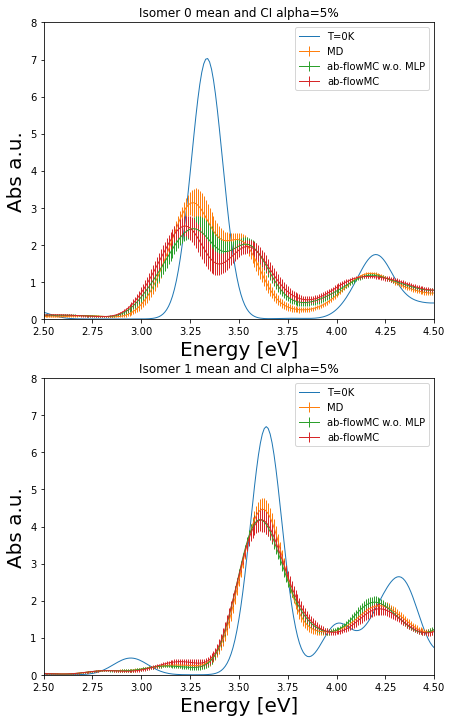

In [37]:
from scipy.stats import t

t = t.ppf(1-0.05/2, n-1)

fig, axs = plt.subplots(2, 1, figsize=(7, 12))

#axes[1].set_title("Isomer 0 mean and std sample")
data0 = data350K_is0_dft[0]
X = data0[:,0]
axs[0].plot(data0K_is0[:,0],data0K_is0[:,1], lw=1, label="T=0K")
axs[0].errorbar(X, data350_md[0]['means'], t*data350_md[0]['stds'], lw=1, label="MD" )
axs[0].errorbar(X, mean_is0_dft, t*std_is0_dft/np.sqrt(n), lw=1, label="ab-flowMC w.o. MLP" )
axs[0].errorbar(X, mean_is0_mlp, t*std_is0_mlp/np.sqrt(n), lw=1, label="ab-flowMC" )


axs[1].plot(data0K_is1[:,0],data0K_is1[:,1], lw=1, label="T=0K")
axs[1].errorbar(X, data350_md[1]['means'], t*data350_md[1]['stds'], lw=1, label="MD" )
axs[1].errorbar(X, mean_is1_dft, t*std_is1_dft/np.sqrt(n), lw=1, label="ab-flowMC w.o. MLP" )
axs[1].errorbar(X, mean_is1_mlp, t*std_is1_mlp/np.sqrt(n), lw=1, label="ab-flowMC" )

for i in range(2):
    axs[i].set_xlim([2.5, 4.5])
    axs[i].set_ylim([0, 8])
    axs[i].set_ylabel("Abs a.u.", size=20)
    axs[i].set_title("Isomer {:d} mean and CI alpha=5%".format(i))
    axs[i].set_xlabel("Energy [eV]", size=20)
    axs[i].set_ylabel("Abs a.u.", size=20)
    axs[i].legend()
